In [1]:
%run stochastic_lite.ipynb

In [2]:
####################
# Inputs
####################

# PSD ~ 1e-42 strain^2 / Hz
# PSD = 2 sigma**2 * deltaT = 2 * sigma**2 / Fs
# = sigma**2 / 512
# sigma = sqrt(1e-42 * 512)

sigma             = np.sqrt(512 * 1e-42) # strain
sigma_inj         = sigma/10.
NSegments         = 50
Fs                = 1024. # Hz
segmentDuration   = 64.0 # s
t0                = 0 # s
TAvg              = 4.0 # s

####################
# Computed quantities
####################

NSamplesPerSegment=int(segmentDuration*Fs) 
deltaT=1/Fs
fNyquist=1/(2*deltaT)
deltaF=1/segmentDuration
deltaFStoch=1/TAvg
NAvgs = 2 * int(segmentDuration / TAvg) - 1
jobDuration = NSegments * segmentDuration

In [3]:
# Theoretical PSD and sigma for white GWB and white noise

Nfreqs = int((Fs/2) / deltaFStoch)
alpha=3 # white signal
fref=25

w1w2bar, w1w2squaredbar,_,_ = window_factors(NSamplesPerSegment)
PSD_theor = 2*(sigma**2)*deltaT
Pgw_theor = 2*(sigma_inj**2)*deltaT

H_theor = (3*H0**2)/(10*np.pi**2*fref**3) # don't need *(P1.freqs/fref)**(alpha-3) for alpha=3
Y_theor = Pgw_theor/H_theor

var_theor = 1./((segmentDuration)*2*Nfreqs*deltaFStoch * H_theor**2/(PSD_theor**2))
var_theor = w1w2squaredbar / w1w2bar**2 * var_theor
sigma_theor = np.sqrt(var_theor)

print('sigma_theor =', sigma_theor)
print('Y_theor =', Y_theor)

sigma_theor = 0.0002666003559166893
Y_theor = 0.0004894401662160896


In [4]:
# simulate the time series data
noise1=sigma*np.random.randn(int(NSamplesPerSegment*NSegments))
noise2=sigma*np.random.randn(int(NSamplesPerSegment*NSegments))
inj=sigma_inj*np.random.randn(int(NSamplesPerSegment*NSegments))

times=np.arange(t0,t0+NSegments*segmentDuration,1/Fs)

d1=TimeSeries(times,noise1 + inj)
d2=TimeSeries(times,noise2 + inj)

In [5]:
# run stochastic pipeline
Ys,sigs,Y_fs,var_fs,segmentStartTimes,freqs=stochastic(d1,d2,segmentDuration,deltaFStoch,
                                                      fref=fref,alpha=alpha)

stochastic: Done with Interval 1 / 95
	Y     = 8.631415e-04
	sigma = 2.641173e-04
	SNR   = 3.268024
stochastic: Done with Interval 2 / 95
	Y     = 7.158243e-04
	sigma = 2.643051e-04
	SNR   = 2.708325
stochastic: Done with Interval 3 / 95
	Y     = 5.759123e-04
	sigma = 2.644467e-04
	SNR   = 2.177801
stochastic: Done with Interval 4 / 95
	Y     = 5.880696e-04
	sigma = 2.642361e-04
	SNR   = 2.225546


/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_35641/1520427049.py:108: RuntimeWarning: divide by zero encountered in divide
  S0 = FrequencySeries(freqs, (3*H0**2)/(10*np.pi**2*freqs**3) )
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_35641/1520427049.py:117: ComplexWarning: Casting complex values to real discards the imaginary part
  Ys[II],sigs[II] = calc_Y_sigma_from_Yf_varf(Y_f.data[1:],var_f.data[1:], freqs=freqs[1:], alpha=alpha, fref=fref)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_35641/1520427049.py:119: ComplexWarning: Casting complex values to real discards the imaginary part
  Y_fs[:,II],var_fs[:,II] = Y_f.data, var_f.data


stochastic: Done with Interval 5 / 95
	Y     = 4.817531e-04
	sigma = 2.648054e-04
	SNR   = 1.819272
stochastic: Done with Interval 6 / 95
	Y     = 3.781652e-04
	sigma = 2.654654e-04
	SNR   = 1.424537
stochastic: Done with Interval 7 / 95
	Y     = 5.236915e-04
	sigma = 2.646444e-04
	SNR   = 1.978850
stochastic: Done with Interval 8 / 95
	Y     = 3.967046e-04
	sigma = 2.641356e-04
	SNR   = 1.501897
stochastic: Done with Interval 9 / 95
	Y     = -4.675497e-04
	sigma = 2.651409e-04
	SNR   = -1.763401
stochastic: Done with Interval 10 / 95
	Y     = 7.513238e-04
	sigma = 2.653314e-04
	SNR   = 2.831643
stochastic: Done with Interval 11 / 95
	Y     = 4.720146e-04
	sigma = 2.636738e-04
	SNR   = 1.790146
stochastic: Done with Interval 12 / 95
	Y     = 8.020450e-04
	sigma = 2.635826e-04
	SNR   = 3.042861
stochastic: Done with Interval 13 / 95
	Y     = 7.014183e-04
	sigma = 2.647523e-04
	SNR   = 2.649337
stochastic: Done with Interval 14 / 95
	Y     = 7.543792e-04
	sigma = 2.650918e-04
	SNR   = 2.

In [6]:
# combine spectra over times

Y_f,var_f=postprocessing_spectra(Y_fs,var_fs,jobDuration,segmentDuration,
                                 deltaFStoch,deltaT)

/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_35641/2966287306.py:14: RuntimeWarning: invalid value encountered in divide
  Y_f_o = np.sum(Y_fs_odds / var_fs_odds,axis=1) / np.sum(1/var_fs_odds,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_35641/2966287306.py:15: RuntimeWarning: divide by zero encountered in divide
  v_f_o = 1/np.sum(1/var_fs_odds,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_35641/2966287306.py:17: RuntimeWarning: invalid value encountered in divide
  Y_f_e = np.sum(Y_fs_evens / var_fs_evens,axis=1) / np.sum(1/var_fs_evens,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_35641/2966287306.py:18: RuntimeWarning: divide by zero encountered in divide
  v_f_e = 1/np.sum(1/var_fs_evens,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_35641/2966287306.py:28: RuntimeWarning: invalid value encountered in subtract
  detC_f = C_f_oo*C_f_ee - C_f_oe**2
/var/folders/h9/8jj76gb51nq2gjkzk76xh3

In [7]:
# combine point estimates and error bars
Y_opt,sig_opt = postprocessing(Ys,sigs,jobDuration,segmentDuration,deltaF,deltaT,bufferSecs=0)

print('Y_opt =', Y_opt)
print('sig_opt =', sig_opt)

Y_opt = 0.0004855631832221126
sig_opt = 5.99811857589322e-05


15:00 bilby INFO    : Running for label 'GWB_powerlaw', output will be saved to 'outdir'
15:00 bilby INFO    : Analysis priors:
15:00 bilby INFO    : A=Uniform(minimum=1e-10, maximum=0.001, name='A', latex_label='A', unit=None, boundary=None)
15:00 bilby INFO    : alpha=Uniform(minimum=-5, maximum=5, name='alpha', latex_label='alpha', unit=None, boundary=None)
15:00 bilby INFO    : Analysis likelihood class: <class '__main__.BasicPowerLawGWBLikelihood'>
15:00 bilby INFO    : Analysis likelihood noise evidence: -1884.8913337060608
15:00 bilby INFO    : Single likelihood evaluation took 1.137e-04 s
15:00 bilby INFO    : Using sampler Dynesty with kwargs {'nlive': 500, 'bound': 'live', 'sample': 'act-walk', 'periodic': None, 'reflective': None, 'update_interval': 600, 'first_update': None, 'npdim': None, 'rstate': None, 'queue_size': 1, 'pool': None, 'use_pool': None, 'live_points': None, 'logl_args': None, 'logl_kwargs': None, 'ptform_args': None, 'ptform_kwargs': None, 'gradient': None,

4592it [00:05, 737.47it/s, bound:101 nc: 18 ncall:8.1e+04 eff:5.7% logz-ratio=135.01+/-nan dlogz:0.105>0.1]      

15:00 bilby INFO    : Written checkpoint file outdir/GWB_powerlaw_resume.pickle


4617it [00:06, 673.89it/s, bound:102 nc:  1 ncall:8.2e+04 eff:6.3% logz-ratio=135.11+/-0.11 dlogz:0.000>0.1]

15:00 bilby INFO    : Rejection sampling nested samples to obtain 1318 posterior samples
15:00 bilby INFO    : Sampling time: 0:00:06.849627
15:00 bilby INFO    : Summary of results:
nsamples: 1318
ln_noise_evidence: -1884.891
ln_evidence: -1749.786 +/-  0.136
ln_bayes_factor: 135.106 +/-  0.136



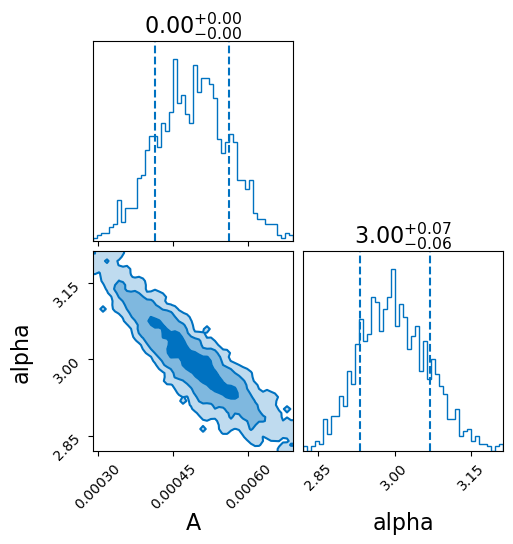

In [8]:
# A few simple setup steps
label = 'GWB_powerlaw'
outdir = 'outdir'

cleanup_dir(outdir)

Amin,Amax,alpha_min,alpha_max=1e-10,1e-3,-5,5
    

fref=25

likelihood = BasicPowerLawGWBLikelihood(Y_f[1:],var_f[1:],freqs[1:],fref)
priors = dict(A=bilby.core.prior.Uniform(Amin,Amax, 'A'),
              alpha=bilby.core.prior.Uniform(alpha_min,alpha_max, 'alpha'))

# And run sampler
result = bilby.run_sampler(
    likelihood=likelihood, priors=priors, sampler='dynesty', npoints=500,
    walks=10, outdir=outdir, label=label,maxmcmc=50000)
result.plot_corner()

In [9]:
A=result.samples[:,0]
alpha=result.samples[:,1]

Text(0.5, 0, '')

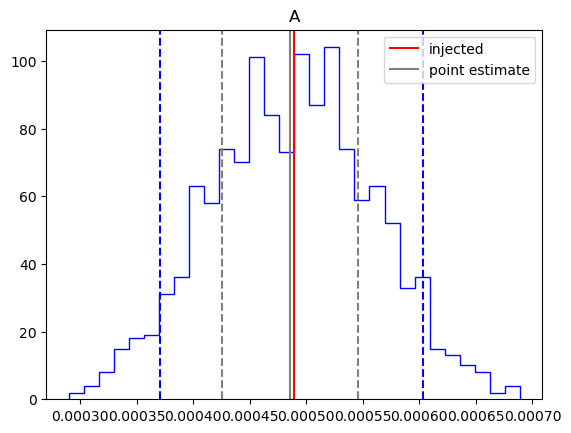

In [10]:
plt.hist(A,bins=30,histtype='step',color='blue')
plt.axvline(np.percentile(A,5),color='blue',linestyle='--')
plt.axvline(np.percentile(A,95),color='blue',linestyle='--')

plt.axvline(Y_theor,color='red', label='injected')
plt.axvline(Y_opt,color='grey', label='point estimate')
plt.axvline(Y_opt+sig_opt,color='grey', linestyle='--')
plt.axvline(Y_opt-sig_opt,color='grey', linestyle='--')

plt.legend()

plt.title('A')
plt.xlabel('')

Text(0.5, 0, '')

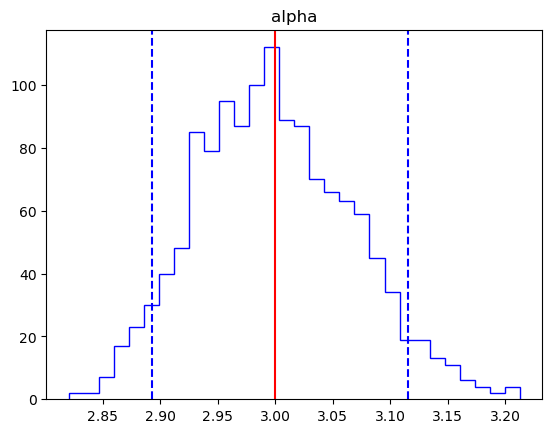

In [11]:
plt.hist(alpha,bins=30,histtype='step',color='blue')
plt.axvline(np.percentile(alpha,5),color='blue',linestyle='--')
plt.axvline(np.percentile(alpha,95),color='blue',linestyle='--')

plt.axvline(3,color='red')

plt.title('alpha')
plt.xlabel('')